BankNote Authentication Classification Project

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    KFold, StratifiedKFold, LeaveOneOut, learning_curve
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc
)
from sklearn.base import clone
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import os
from sklearn import metrics
from imblearn.over_sampling import SMOTE

 Data Preparation and Exploration

In [30]:
print("◼ Data Preparation and Exploration")
# File path correction
csv_file_path = "BankNote_Authentication.csv"  # Default path
if not os.path.exists(csv_file_path):
    csv_file_path = "../" + csv_file_path  
    if not os.path.exists(csv_file_path):
        print(f"Error: File 'BankNote_Authentication.csv' not found. Please ensure the file is in the same directory as the script or provide the correct path.")
        exit() 

df = pd.read_csv(csv_file_path)

# Basic data exploration
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print("\nDescriptive Statistics:")
print(df.describe())
print("\nClass distribution:")
class_dist = df['class'].value_counts()
print(class_dist)
print("\nMissing values:")
print(df.isnull().sum())

◼ Data Preparation and Exploration

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None

First 5 rows:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Descriptive Statistics:
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627 

Class Distribution Before Balancing

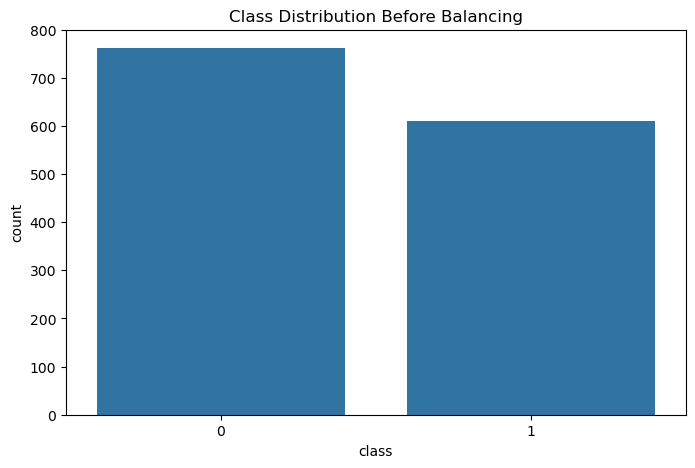

In [31]:
# Visualize class imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=df)
plt.title('Class Distribution Before Balancing')
plt.show()

Data Balancing Using SMOTE

In [ ]:
print("\n◼ Balancing the Dataset")

X = df.drop('class', axis=1)
y = df['class']

# Apply SMOTE (Synthetic Minority Over-sampling Technique)
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

df_balanced = pd.DataFrame(X_balanced, columns=X.columns)
df_balanced['class'] = y_balanced

print("\nClass distribution after balancing:")
print(df_balanced['class'].value_counts())


◼ Balancing the Dataset

Class distribution after balancing:
class
0    762
1    762
Name: count, dtype: int64


 Class Distribution After Balancing

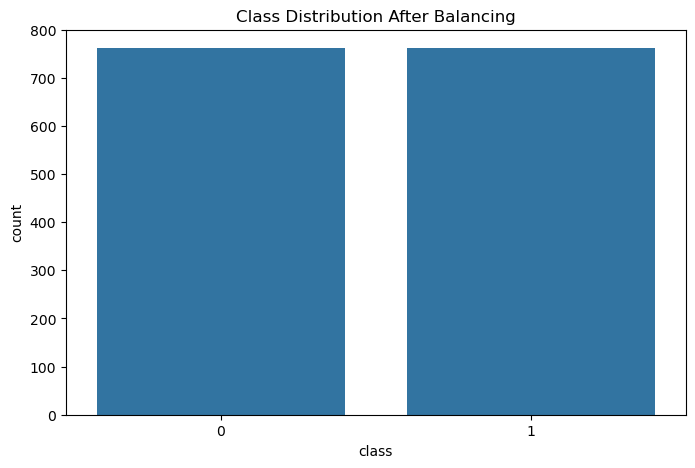

In [33]:
# Visualize balanced classes
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=df_balanced)
plt.title('Class Distribution After Balancing')
plt.show()

# Continue with the balanced dataset
df = df_balanced.copy()

Outlier Detection Using Boxplots


◼ Outlier Handling


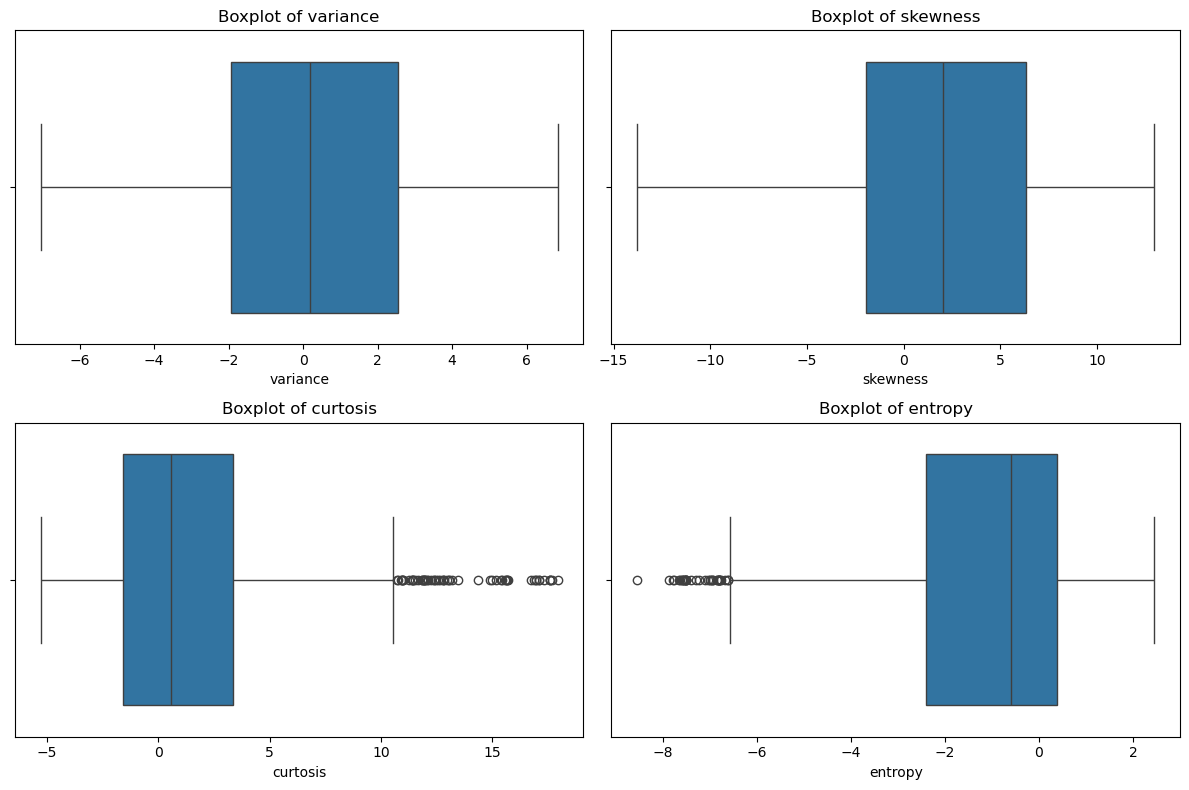

In [34]:
print("\n◼ Outlier Handling")
plt.figure(figsize=(12, 8))
for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

Correlation Heatmap

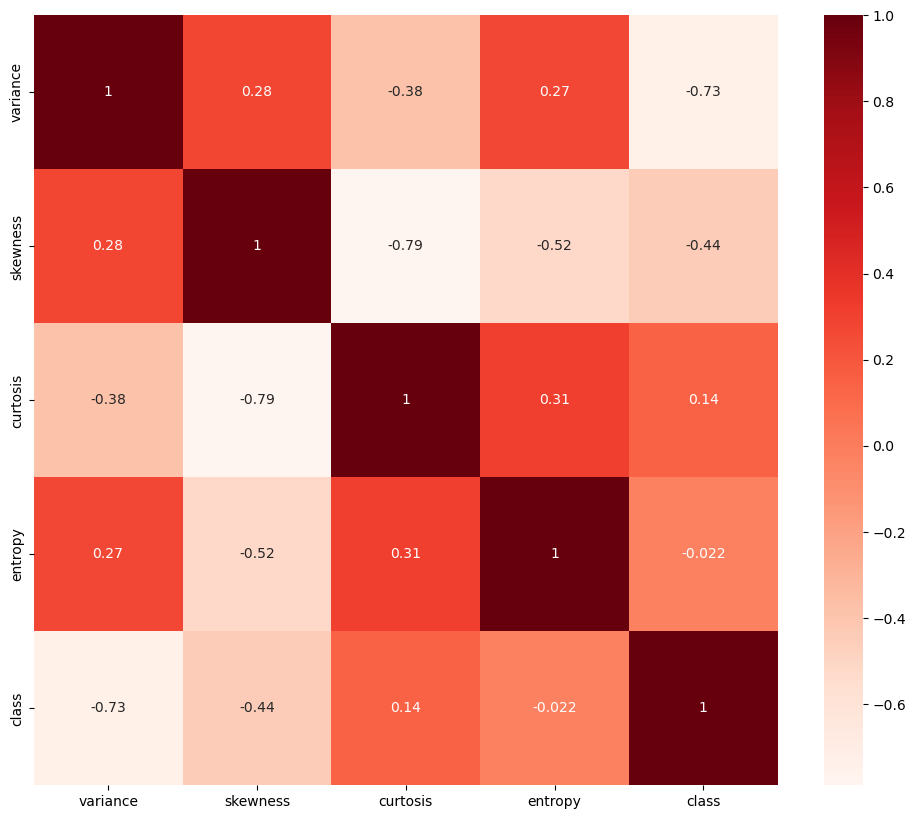

In [35]:
#Using Pearson Correlation to create Correlation heatmap
plt.figure(figsize=(12,10))
cor = df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

Data Normalization with MinMaxScaler

In [36]:
print("\n◼ Data Normalization")
print(f"Original dataset shape: {df_no_outliers.shape}")
print("First 5 rows before normalization:")
print(df_no_outliers.head())

scaler = MinMaxScaler()
features = df_no_outliers.drop('class', axis=1)
target = df_no_outliers['class']
features_normalized = scaler.fit_transform(features)
df_normalized = pd.DataFrame(features_normalized, columns=features.columns)
df_normalized['class'] = target.values

print("\nAfter normalization:")
print(f"Normalized dataset shape: {df_normalized.shape}")
print("First 5 rows after normalization:")
print(df_normalized.head())
print("\nNormalization summary (per feature):")
print(df_normalized.describe().loc[['min', 'max']]) 


◼ Data Normalization
Original dataset shape: (1425, 5)
First 5 rows before normalization:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

After normalization:
Normalized dataset shape: (1425, 5)
First 5 rows after normalization:
   variance  skewness  curtosis   entropy  class
0  0.769004  0.820084  0.156622  0.678335      0
1  0.835659  0.799148  0.178655  0.565603      0
2  0.786629  0.345498  0.455581  0.739796      0
3  0.757105  0.856051  0.080554  0.328803      0
4  0.531578  0.269221  0.622869  0.618165      0

Normalization summary (per feature):
     variance  skewness  curtosis  entropy  class
min       0.0       0.0       0.0      0.0    0.0
max       1.0       1.0       1.0      1.0    1.0


Train, Validation, and Test Split

In [38]:
print("\n◼ Train-Test Split")
X = df_normalized.drop('class', axis=1)
y = df_normalized['class']

print(f"Total samples: {len(df_normalized)}")
print(f"Class distribution (original):\n{y.value_counts(normalize=True)}")

# Split test, train, and validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=56, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=1/9, random_state=56, stratify=y_train)

print("\nSplit results:")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nClass distribution in splits:")
print("Training set:\n", y_train.value_counts(normalize=True))
print("Validation set:\n", y_val.value_counts(normalize=True))
print("Test set:\n", y_test.value_counts(normalize=True))


◼ Train-Test Split
Total samples: 1425
Class distribution (original):
class
0    0.522105
1    0.477895
Name: proportion, dtype: float64

Split results:
Training set: 1139 samples (79.9%)
Validation set: 143 samples (10.0%)
Test set: 143 samples (10.0%)

Class distribution in splits:
Training set:
 class
0    0.52151
1    0.47849
Name: proportion, dtype: float64
Validation set:
 class
0    0.524476
1    0.475524
Name: proportion, dtype: float64
Test set:
 class
0    0.524476
1    0.475524
Name: proportion, dtype: float64


Evaluation Metrics Overview

In [39]:
print("\n◼ Evaluation Metrics")
print("""
Common metrics for classifier evaluation:
- Accuracy: (TP + TN) / (TP + TN + FP + FN)
- Precision: TP / (TP + FP) - How many selected items are relevant?
- Recall: TP / (TP + FN) - How many relevant items are selected?
- F1 Score: Harmonic mean of precision and recall
- AUC-ROC: Area Under the ROC Curve
""") 


◼ Evaluation Metrics

Common metrics for classifier evaluation:
- Accuracy: (TP + TN) / (TP + TN + FP + FN)
- Precision: TP / (TP + FP) - How many selected items are relevant?
- Recall: TP / (TP + FN) - How many relevant items are selected?
- F1 Score: Harmonic mean of precision and recall
- AUC-ROC: Area Under the ROC Curve



Model Evaluation Function

In [40]:
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    print(f"\n=== Evaluating {model_name} ===")

    # Holdout Method
    print("\n◼ Holdout Method Evaluation")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\nHoldout Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Cross-Validation Methods
    print("\n◼ Cross-Validation Methods")

    print("\n• K-Fold Cross-Validation (k=5):")
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"CV Scores: {cv_scores}")
    print(f"Mean Accuracy: {cv_scores.mean():.4f}")

    print("\n• Stratified K-Fold CV:")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    stratified_scores = cross_val_score(model, X_train, y_train, cv=skf)
    print(f"Stratified CV Scores: {stratified_scores}")
    print(f"Mean Accuracy: {stratified_scores.mean():.4f}")

    print("\n• Leave-One-Out Cross-Validation:")
    loo = LeaveOneOut()
    loocv_scores = cross_val_score(model, X_train, y_train, cv=loo)
    print(f"LOOCV Accuracy: {loocv_scores.mean():.4f}")

    # Bootstrap Method
    print("\n◼ Bootstrap Evaluation")
    n_iterations = 500
    n_size = int(len(X_train) * 0.8)
    bootstrap_accuracies = []

    for _ in range(n_iterations):
        indices = np.random.choice(len(X_train), size=n_size, replace=True)
        X_sample, y_sample = X_train.iloc[indices], y_train.iloc[indices]
        model_clone = clone(model)
        model_clone.fit(X_sample, y_sample)
        y_pred_bootstrap = model_clone.predict(X_test)
        bootstrap_accuracies.append(accuracy_score(y_test, y_pred_bootstrap))

    print(f"Mean Bootstrap Accuracy: {np.mean(bootstrap_accuracies):.4f}")
    print(f"95% Confidence Interval: [{np.percentile(bootstrap_accuracies, 2.5):.4f}, {np.percentile(bootstrap_accuracies, 97.5):.4f}]")

    # ROC Curve Analysis
    print("\n◼ ROC Curve Analysis")
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred

    if hasattr(model, "predict_proba") or hasattr(model, "decision_function"):
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("ROC Curve not available for this model")
        roc_auc = 0

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'stratified_cv_mean': stratified_scores.mean(),
        'loocv': loocv_scores.mean(),
        'bootstrap_mean': np.mean(bootstrap_accuracies),
        'roc_auc': roc_auc
    }

 Model Training and Evaluation

In [41]:
print("\n◼ Model Training and Evaluation")

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced')
}


◼ Model Training and Evaluation


Initial KNN with k=10

In [43]:
from sklearn.neighbors import KNeighborsClassifier as KNN

clf = KNN(n_neighbors=10)
clf.fit(X_train, y_train)
test_predict = clf.predict(X_test)
print("Recall:", recall_score(y_test, test_predict),
      "\nF1 Score:", f1_score(y_test, test_predict),
      "\nAccuracy:", accuracy_score(y_test, test_predict))

Recall: 1.0 
F1 Score: 1.0 
Accuracy: 1.0


KNN Elbow Method

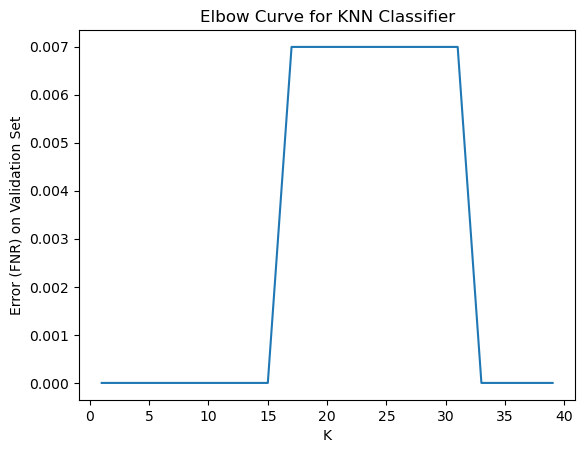

In [44]:
def Elbow(K):
    clf = KNN(n_neighbors=K)
    clf.fit(X_train, y_train)
    valid_predict = clf.predict(X_val)
    acc = accuracy_score(y_val, valid_predict)
    return 1 - acc

k = list(range(1, 40, 2))
er = list(map(Elbow, k))

plt.plot(k, er)
plt.xlabel("K")
plt.ylabel("Error (FNR) on Validation Set")
plt.title("Elbow Curve for KNN Classifier") 
plt.show()

Optimal KNN Model

In [45]:
optimum_k = k[er.index(min(er))]
print(f"Optimum K: {optimum_k}")
clf = KNN(n_neighbors=optimum_k)
clf.fit(X_train, y_train)
test_predict = clf.predict(X_test)
print("Recall:", recall_score(y_test, test_predict),
    "\nF1 Score:", f1_score(y_test, test_predict),
    "\nAccuracy:", accuracy_score(y_test, test_predict)) 
models['KNN'] = clf

Optimum K: 1
Recall: 1.0 
F1 Score: 0.9927007299270073 
Accuracy: 0.993006993006993


Hyperparameter Tuning for SVM

In [46]:
print("\n◼ Hyperparameter Tuning") 
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
    'class_weight': ['balanced']
}
grid_search_svm = GridSearchCV(SVC(random_state=42, probability=True), param_grid_svm, cv=5)
grid_search_svm.fit(X_train, y_train)
best_svm_model = grid_search_svm.best_estimator_
models['SVM'] = best_svm_model
print(f"Best SVM params: {grid_search_svm.best_params_}")


◼ Hyperparameter Tuning
Best SVM params: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}


Decision Tree Optimization

In [47]:
print("\n◼ Improving Decision Tree")
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'ccp_alpha': [0.0, 0.01, 0.1],
    'class_weight': ['balanced']
}

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                             param_grid_dt, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)

best_dt_model = grid_search_dt.best_estimator_
models['Decision Tree'] = best_dt_model
print(f"Best Decision Tree params: {grid_search_dt.best_params_}") 


◼ Improving Decision Tree
Best Decision Tree params: {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}


c:\Users\salma\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Evaluate All Models


=== Evaluating Decision Tree ===

◼ Holdout Method Evaluation

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        75
           1       0.99      0.97      0.98        68

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143


Confusion Matrix:
[[74  1]
 [ 2 66]]

Holdout Metrics:
Accuracy: 0.9790
Precision: 0.9851
Recall: 0.9706
F1 Score: 0.9778

◼ Cross-Validation Methods

• K-Fold Cross-Validation (k=5):
CV Scores: [0.98245614 0.99561404 0.98245614 0.97807018 0.97356828]
Mean Accuracy: 0.9824

• Stratified K-Fold CV:
Stratified CV Scores: [0.96929825 0.97807018 0.97807018 0.99561404 0.97356828]
Mean Accuracy: 0.9789

• Leave-One-Out Cross-Validation:
LOOCV Accuracy: 0.9772

◼ Bootstrap Evaluation
Mean Bootstrap Accuracy: 0.9735
95% Confidence Interval: [0.9441, 0.9930]

◼ ROC Curve Analysis


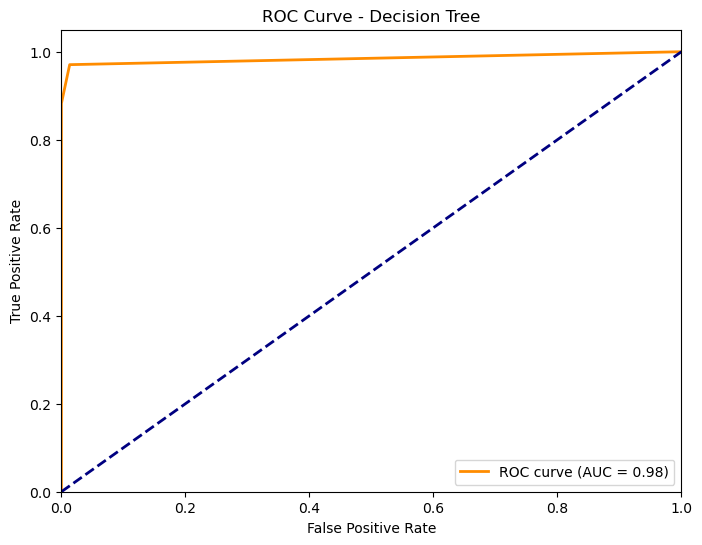


=== Evaluating Naive Bayes ===

◼ Holdout Method Evaluation

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        75
           1       0.89      0.93      0.91        68

    accuracy                           0.91       143
   macro avg       0.91      0.91      0.91       143
weighted avg       0.91      0.91      0.91       143


Confusion Matrix:
[[67  8]
 [ 5 63]]

Holdout Metrics:
Accuracy: 0.9091
Precision: 0.8873
Recall: 0.9265
F1 Score: 0.9065

◼ Cross-Validation Methods

• K-Fold Cross-Validation (k=5):
CV Scores: [0.86403509 0.87280702 0.86842105 0.86403509 0.8722467 ]
Mean Accuracy: 0.8683

• Stratified K-Fold CV:
Stratified CV Scores: [0.8245614  0.89035088 0.88157895 0.86403509 0.88986784]
Mean Accuracy: 0.8701

• Leave-One-Out Cross-Validation:
LOOCV Accuracy: 0.8683

◼ Bootstrap Evaluation
Mean Bootstrap Accuracy: 0.9109
95% Confidence Interval: [0.8951, 0.9337]

◼ ROC Curve Analysis


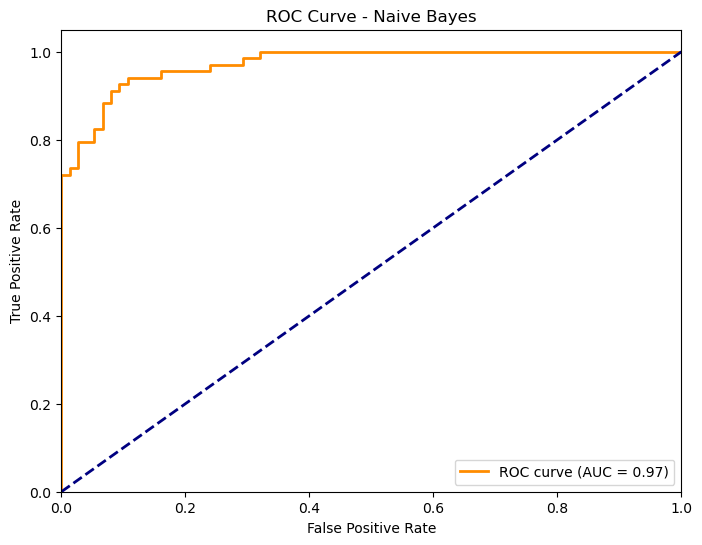


=== Evaluating KNN ===

◼ Holdout Method Evaluation

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        75
           1       0.99      1.00      0.99        68

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143


Confusion Matrix:
[[74  1]
 [ 0 68]]

Holdout Metrics:
Accuracy: 0.9930
Precision: 0.9855
Recall: 1.0000
F1 Score: 0.9927

◼ Cross-Validation Methods

• K-Fold Cross-Validation (k=5):
CV Scores: [0.99561404 1.         1.         1.         0.99559471]
Mean Accuracy: 0.9982

• Stratified K-Fold CV:
Stratified CV Scores: [1.         0.99561404 1.         1.         1.        ]
Mean Accuracy: 0.9991

• Leave-One-Out Cross-Validation:
LOOCV Accuracy: 0.9982

◼ Bootstrap Evaluation
Mean Bootstrap Accuracy: 0.9933
95% Confidence Interval: [0.9930, 1.0000]

◼ ROC Curve Analysis


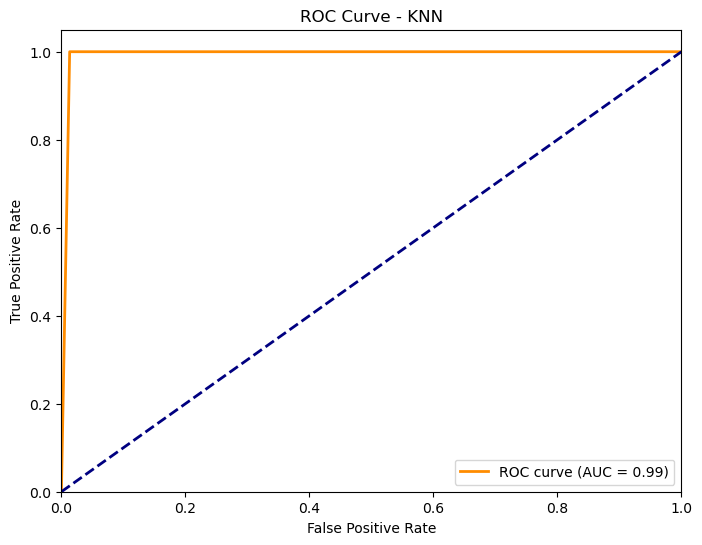


=== Evaluating SVM ===

◼ Holdout Method Evaluation

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        68

    accuracy                           1.00       143
   macro avg       1.00      1.00      1.00       143
weighted avg       1.00      1.00      1.00       143


Confusion Matrix:
[[75  0]
 [ 0 68]]

Holdout Metrics:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

◼ Cross-Validation Methods

• K-Fold Cross-Validation (k=5):
CV Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0000

• Stratified K-Fold CV:
Stratified CV Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0000

• Leave-One-Out Cross-Validation:
LOOCV Accuracy: 1.0000

◼ Bootstrap Evaluation
Mean Bootstrap Accuracy: 1.0000
95% Confidence Interval: [1.0000, 1.0000]

◼ ROC Curve Analysis


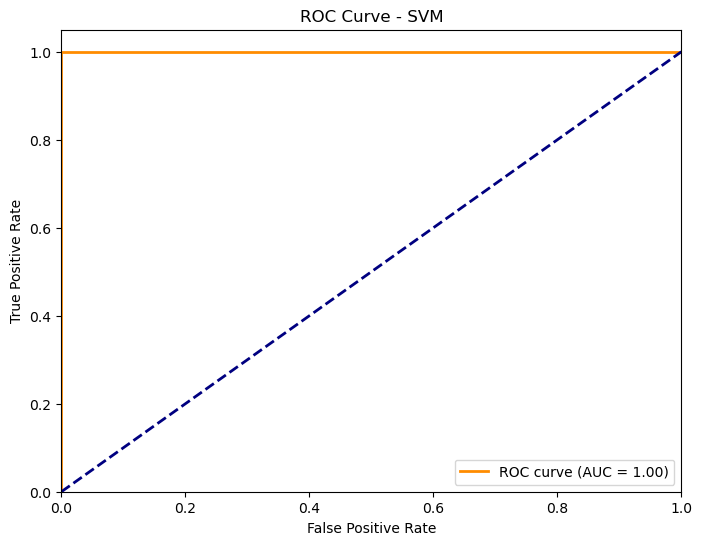

In [48]:
results = []
for name, model in models.items():
    results.append(evaluate_model(model, name, X_train, y_train, X_test, y_test)) 

Model Comparison

In [49]:

results_df = pd.DataFrame(results)
print("\nPerformance Comparison:")
print(results_df)


Performance Comparison:
      model_name  accuracy  precision    recall        f1   cv_mean  \
0  Decision Tree  0.979021   0.985075  0.970588  0.977778  0.982433   
1    Naive Bayes  0.909091   0.887324  0.926471  0.906475  0.868309   
2            KNN  0.993007   0.985507  1.000000  0.992701  0.998242   
3            SVM  1.000000   1.000000  1.000000  1.000000  1.000000   

   stratified_cv_mean     loocv  bootstrap_mean   roc_auc  
0            0.978924  0.977173        0.973497  0.984510  
1            0.870079  0.868306        0.910895  0.972549  
2            0.999123  0.998244        0.993315  0.993333  
3            1.000000  1.000000        1.000000  1.000000  


 Accuracy Comparison Plot

C:\Users\salma\AppData\Local\Temp\ipykernel_23652\2768452729.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_name', y='accuracy', data=results_df, palette='viridis')


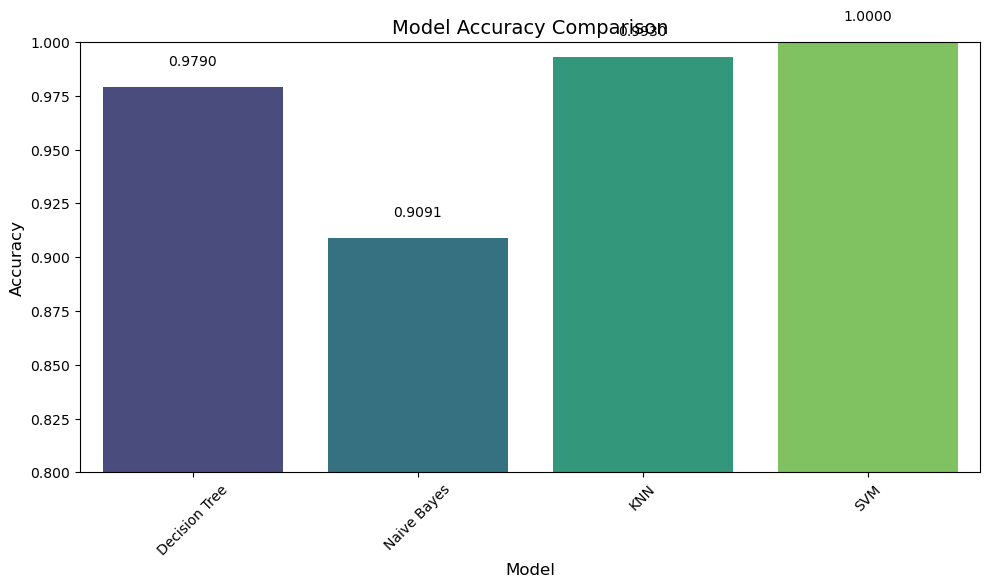

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(x='model_name', y='accuracy', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.8, 1.0)
plt.xticks(rotation=45)
for i, acc in enumerate(results_df['accuracy']):
    plt.text(i, acc + 0.01, f'{acc:.4f}', ha='center') 
plt.tight_layout()
plt.show()

ROC AUC Comparison Plot

C:\Users\salma\AppData\Local\Temp\ipykernel_23652\2510426158.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_name', y='roc_auc', data=roc_models, palette='mako')


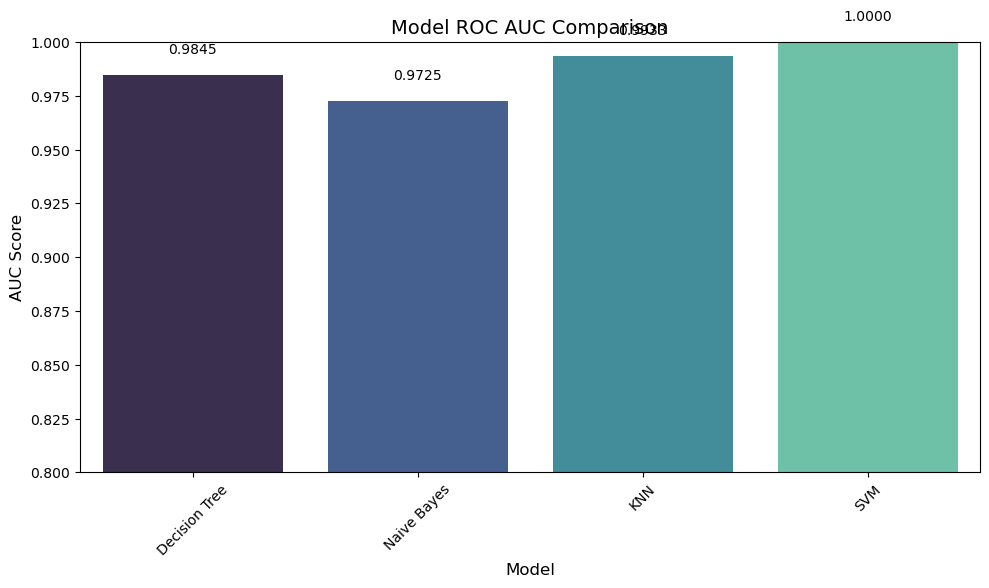

In [51]:
roc_models = results_df[results_df['roc_auc'].notna()]
if not roc_models.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='model_name', y='roc_auc', data=roc_models, palette='mako')
    plt.title('Model ROC AUC Comparison', fontsize=14)
    plt.ylabel('AUC Score', fontsize=12)
    plt.xlabel('Model', fontsize=12)
    plt.ylim(0.8, 1.0)
    plt.xticks(rotation=45)
    for i, auc_score in enumerate(roc_models['roc_auc']):
        plt.text(i, auc_score + 0.01, f'{auc_score:.4f}', ha='center') 
    plt.tight_layout()
    plt.show()

Confusion Matrices


◼ Confusion Matrices


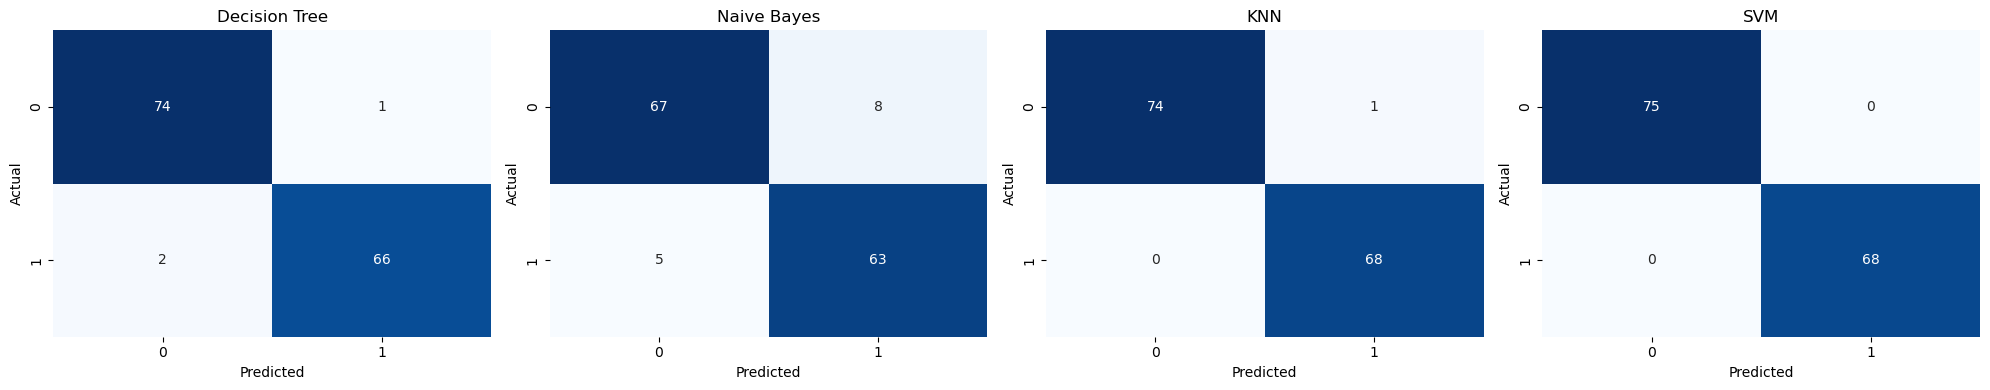

In [52]:
print("\n◼ Confusion Matrices")
fig, axes = plt.subplots(1, len(models), figsize=(20, 4))
for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

Learning Curves


◼ Learning Curves


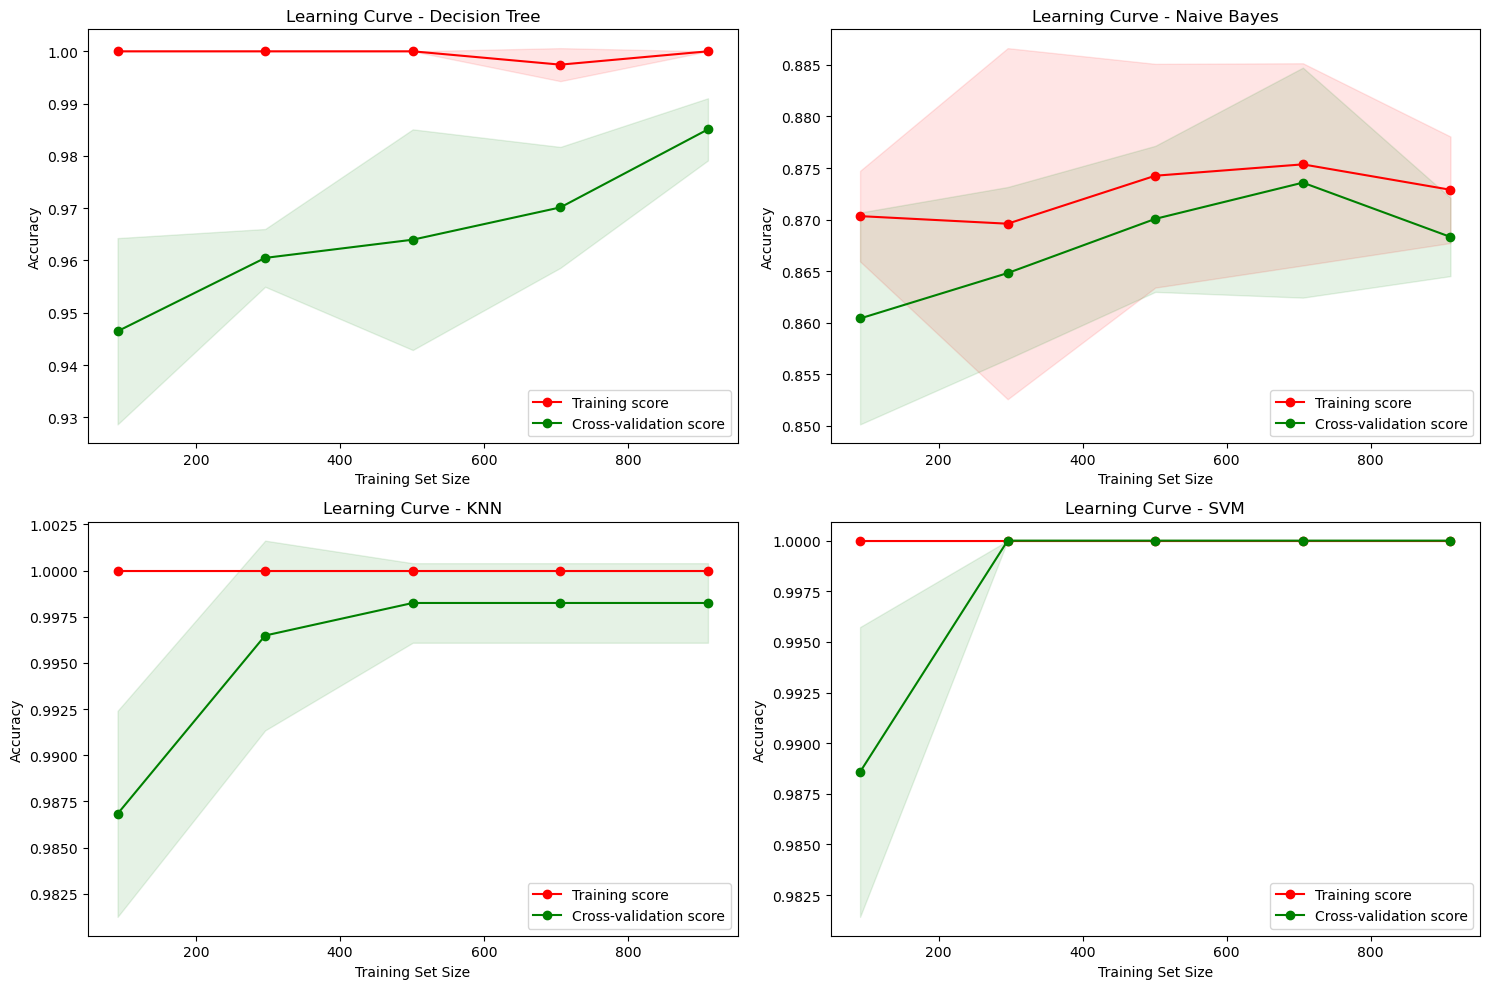

In [53]:
print("\n◼ Learning Curves")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (name, model) in zip(axes.flatten(), models.items()):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    ax.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    ax.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
    ax.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color='r')
    ax.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1,
                     color='g') 
    ax.set_title(f'Learning Curve - {name}')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Accuracy') 
    ax.legend(loc='best') 
plt.tight_layout()
plt.show()